In [1]:
import os

In [2]:
os.getcwd()

'/content'

In [4]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [7]:
df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")

In [8]:
df.shape

(299, 13)

In [10]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [14]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [15]:
df["DEATH_EVENT"].value_counts()

,count
DEATH_EVENT,
0,203
1,96


In [16]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (299, 12)
Target shape: (299,)


In [19]:
X_temp, X_test, y_temp, y_test = train_test_split( X, y,test_size=0.20,random_state=42,stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp,test_size=0.25,random_state=42,stratify=y_temp)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (179, 12)
Validation shape: (60, 12)
Test shape: (60, 12)


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [45]:
def evaluate_sklearn_model(model, X_data, y_data, name="Model"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    acc = accuracy_score(y_data, y_pred)
    auc = roc_auc_score(y_data, y_prob)

    print(f"\n{name}")
    print("Accuracy:", round(acc, 4))
    print("ROC-AUC :", round(auc, 4))

    return acc, auc


def evaluate_keras_model(model, X_data, y_data, name="Model"):
    y_prob = model.predict(X_data).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_data, y_pred)
    auc = roc_auc_score(y_data, y_prob)

    print(f"\n{name}")
    print("Accuracy:", round(acc, 4))
    print("ROC-AUC :", round(auc, 4))

    return acc, auc


def plot_history(history, title_prefix="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} - Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} - Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


def build_mlp(hidden_units=32, activation="relu", dropout_rate=0.0, l2_reg=0.0):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))
    model.add(Dense(hidden_units, activation=activation,
                    kernel_regularizer=l2(l2_reg)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [24]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_val_acc, log_val_auc = evaluate_sklearn_model(
    log_reg, X_val_scaled, y_val, name="Logistic Regression - Validation")

log_test_acc, log_test_auc = evaluate_sklearn_model(
    log_reg, X_test_scaled, y_test, name="Logistic Regression - Test")


Logistic Regression - Validation
Accuracy: 0.8167
ROC-AUC : 0.923

Logistic Regression - Test
Accuracy: 0.7833
ROC-AUC : 0.8331


In [46]:
mlp_relu = build_mlp(hidden_units=32, activation="relu")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_relu = mlp_relu.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

mlp_val_acc, mlp_val_auc = evaluate_keras_model(
    mlp_relu, X_val_scaled, y_val, name="MLP ReLU - Validation"
)

mlp_test_acc, mlp_test_auc = evaluate_keras_model(
    mlp_relu, X_test_scaled, y_test, name="MLP ReLU - Test"
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5880 - loss: 0.6775 - val_accuracy: 0.5833 - val_loss: 0.6612
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6505 - loss: 0.6358 - val_accuracy: 0.6333 - val_loss: 0.6274
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6855 - loss: 0.6042 - val_accuracy: 0.7000 - val_loss: 0.5980
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7100 - loss: 0.5773 - val_accuracy: 0.6833 - val_loss: 0.5728
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7381 - loss: 0.5542 - val_accuracy: 0.7167 - val_loss: 0.5511
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7541 - loss: 0.5337 - val_accuracy: 0.7167 - val_loss: 0.5317
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7895 - loss: 0.5155 - val_accuracy: 0.7500 - val_loss: 0.5144
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7875 - loss: 0.4989 - val_accuracy: 0.

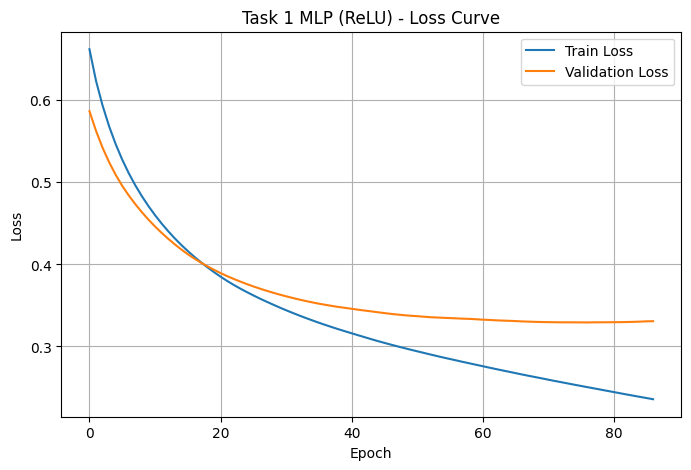

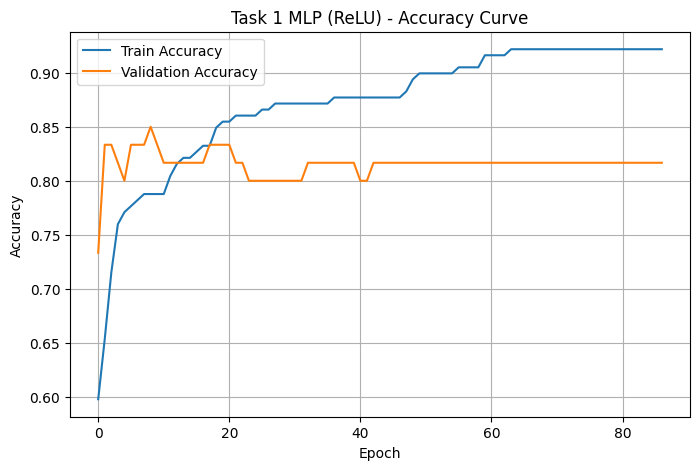

In [27]:
plot_history(history_relu, title_prefix="Task 1 MLP (ReLU)")

In [29]:
task1_results = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP ReLU"],
    "Validation Accuracy": [log_val_acc, mlp_val_acc],
    "Validation ROC-AUC": [log_val_auc, mlp_val_auc],
    "Test Accuracy": [log_test_acc, mlp_test_acc],
    "Test ROC-AUC": [log_test_auc, mlp_test_auc]
})

task1_results

,Model,Validation Accuracy,Validation ROC-AUC,Test Accuracy,Test ROC-AUC
0,Logistic Regression,0.816667,0.922978,0.783333,0.833119
1,MLP ReLU,0.816667,0.922978,0.800000,0.812580


Logistic Regression is a linear model because it uses a weighted sum of the input features
to make predictions it cannot naturally learn complex nonlinear relationships.

The MLP has a hidden layer and ReLU activation so it can learn more complex patterns if the MLP performs better it may be because the dataset contains nonlinear relationships.
If training performance is much higher than validation performance that may suggest overfitting.


## **Task 2 **

In [30]:
relu_model = build_mlp(hidden_units=32, activation="relu")

history_relu2 = relu_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

relu_val_acc, relu_val_auc = evaluate_keras_model(
    relu_model, X_val_scaled, y_val, name="ReLU Model - Validation"
)

relu_test_acc, relu_test_auc = evaluate_keras_model(
    relu_model, X_test_scaled, y_test, name="ReLU Model - Test"
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.5515 - loss: 0.7436 - val_accuracy: 0.6500 - val_loss: 0.6501
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5637 - loss: 0.6898 - val_accuracy: 0.6667 - val_loss: 0.6133
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5960 - loss: 0.6487 - val_accuracy: 0.7000 - val_loss: 0.5815
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6665 - loss: 0.6134 - val_accuracy: 0.7000 - val_loss: 0.5541
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6853 - loss: 0.5824 - val_accuracy: 0.7333 - val_loss: 0.5307
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7006 - loss: 0.5549 - val_accuracy: 0.7500 - val_loss: 0.5106
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7249 - loss: 0.5304 - val_accuracy: 0.7667 - val_loss: 0.4935
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7481 - loss: 0.5087 - val_accuracy: 0

In [31]:
tanh_model = build_mlp(hidden_units=32, activation="tanh")

history_tanh = tanh_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

tanh_val_acc, tanh_val_auc = evaluate_keras_model(
    tanh_model, X_val_scaled, y_val, name="tanh Model - Validation"
)

tanh_test_acc, tanh_test_auc = evaluate_keras_model(
    tanh_model, X_test_scaled, y_test, name="tanh Model - Test"
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.3315 - loss: 0.9693 - val_accuracy: 0.2667 - val_loss: 1.0361
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3896 - loss: 0.8823 - val_accuracy: 0.3167 - val_loss: 0.9504
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4499 - loss: 0.8090 - val_accuracy: 0.4000 - val_loss: 0.8742
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5247 - loss: 0.7450 - val_accuracy: 0.4667 - val_loss: 0.8069
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5458 - loss: 0.6894 - val_accuracy: 0.5167 - val_loss: 0.7481
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6305 - loss: 0.6416 - val_accuracy: 0.6000 - val_loss: 0.6969
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6646 - loss: 0.6005 - val_accuracy: 0.6500 - val_loss: 0.6525
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7280 - loss: 0.5654 - val_accuracy: 0.

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

tanh Model - Validation
Accuracy: 0.8
ROC-AUC : 0.9191
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

tanh Model - Test
Accuracy: 0.7833
ROC-AUC : 0.8601


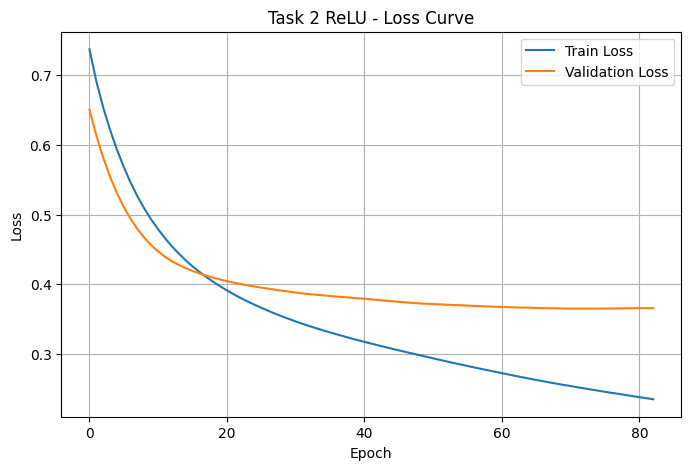

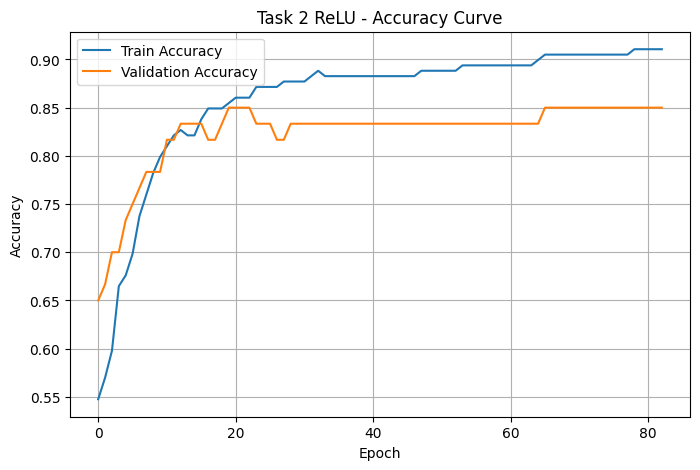

In [32]:
plot_history(history_relu2, title_prefix="Task 2 ReLU")


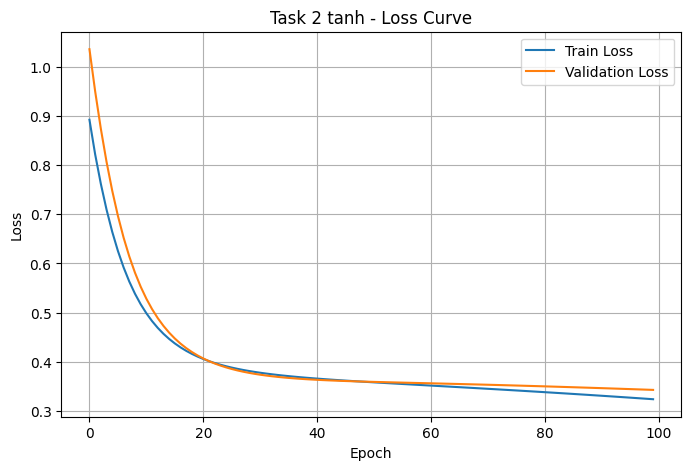

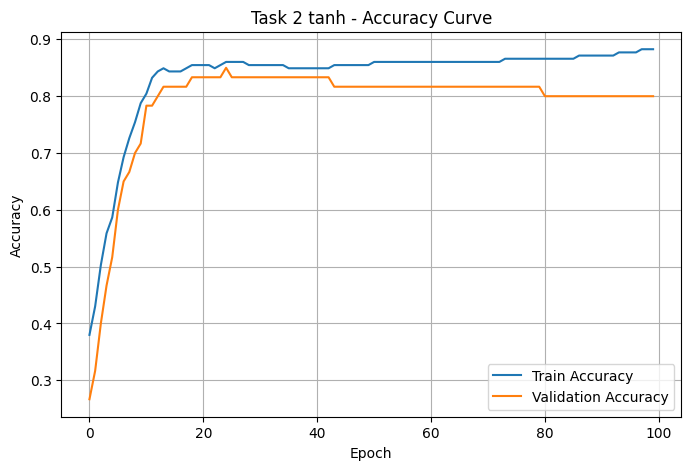

In [33]:
plot_history(history_tanh, title_prefix="Task 2 tanh")

ReLU usually learns faster because it does not saturate for positive values in the same way as tanh
The tanh activation function can suffer from gradient saturation, especially when outputs get close to -1 or 1

ReLU can have the dying ReLU problem where some neurons stop updating if they always output zero

From the learning curves I can compare training speed stability and validation performance

# **Task 3**


In [34]:
small_model = build_mlp(hidden_units=8, activation="relu")

history_small = small_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

small_val_acc, small_val_auc = evaluate_keras_model(
    small_model, X_val_scaled, y_val, name="Small Network - Validation"
)

small_test_acc, small_test_auc = evaluate_keras_model(
    small_model, X_test_scaled, y_test, name="Small Network - Test"
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5046 - loss: 0.7533 - val_accuracy: 0.5333 - val_loss: 0.6845
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5405 - loss: 0.7353 - val_accuracy: 0.5667 - val_loss: 0.6695
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5664 - loss: 0.7202 - val_accuracy: 0.6333 - val_loss: 0.6554
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5920 - loss: 0.7059 - val_accuracy: 0.6667 - val_loss: 0.6424
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6229 - loss: 0.6926 - val_accuracy: 0.6833 - val_loss: 0.6302
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6283 - loss: 0.6802 - val_accuracy: 0.6833 - val_loss: 0.6188
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6359 - loss: 0.6684 - val_accuracy: 0.7000 - val_loss: 0.6079
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6268 - loss: 0.6571 - val_accuracy: 0.

In [35]:
large_model = build_mlp(hidden_units=128, activation="relu")

history_large = large_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

large_val_acc, large_val_auc = evaluate_keras_model(
    large_model, X_val_scaled, y_val, name="Large Network - Validation"
)

large_test_acc, large_test_auc = evaluate_keras_model(
    large_model, X_test_scaled, y_test, name="Large Network - Test"
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.6016 - loss: 0.6585 - val_accuracy: 0.8167 - val_loss: 0.5958
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8083 - loss: 0.5684 - val_accuracy: 0.7833 - val_loss: 0.5458
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8235 - loss: 0.5136 - val_accuracy: 0.7667 - val_loss: 0.5100
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8299 - loss: 0.4741 - val_accuracy: 0.7667 - val_loss: 0.4831
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8364 - loss: 0.4437 - val_accuracy: 0.7667 - val_loss: 0.4621
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8459 - loss: 0.4189 - val_accuracy: 0.7833 - val_loss: 0.4454
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8749 - loss: 0.3984 - val_accuracy: 0.7833 - val_loss: 0.4321
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8705 - loss: 0.3813 - val_accuracy: 0.

In [36]:
regularised_model = build_mlp(hidden_units=128, activation="relu", l2_reg=0.01)

history_regularised = regularised_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

reg_val_acc, reg_val_auc = evaluate_keras_model(
    regularised_model, X_val_scaled, y_val, name="Large Network + L2 - Validation"
)

reg_test_acc, reg_test_auc = evaluate_keras_model(
    regularised_model, X_test_scaled, y_test, name="Large Network + L2 - Test"
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6101 - loss: 0.8732 - val_accuracy: 0.8167 - val_loss: 0.7659
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7484 - loss: 0.7765 - val_accuracy: 0.8333 - val_loss: 0.7073
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8434 - loss: 0.7156 - val_accuracy: 0.8167 - val_loss: 0.6666
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8622 - loss: 0.6717 - val_accuracy: 0.8000 - val_loss: 0.6369
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8652 - loss: 0.6372 - val_accuracy: 0.7833 - val_loss: 0.6136
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8746 - loss: 0.6084 - val_accuracy: 0.7833 - val_loss: 0.5945
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8807 - loss: 0.5836 - val_accuracy: 0.7833 - val_loss: 0.5778
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8820 - loss: 0.5617 - val_accuracy: 0.

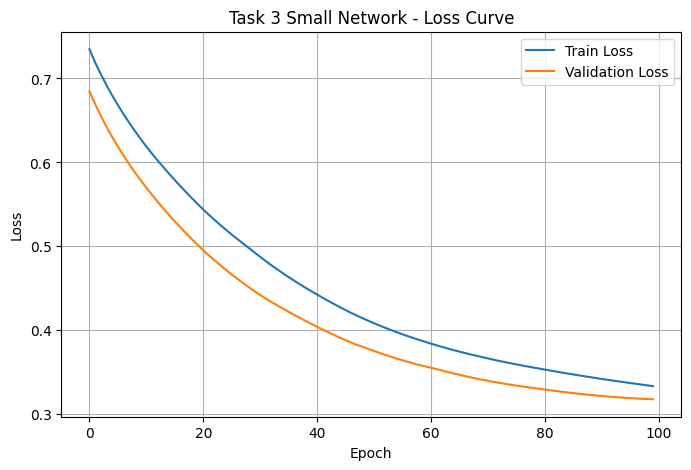

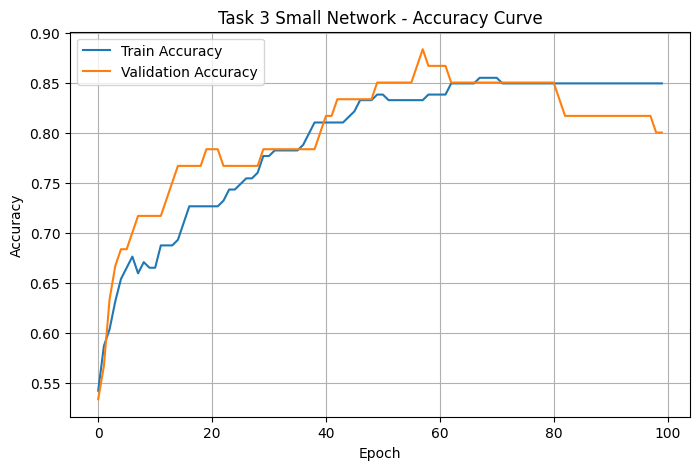

In [38]:
plot_history(history_small, title_prefix="Task 3 Small Network")

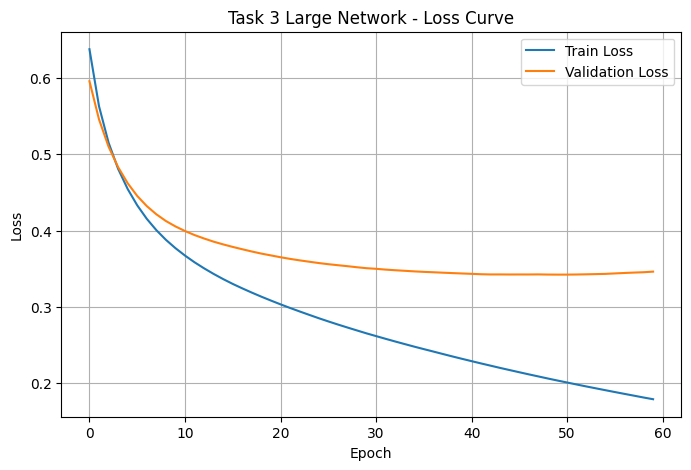

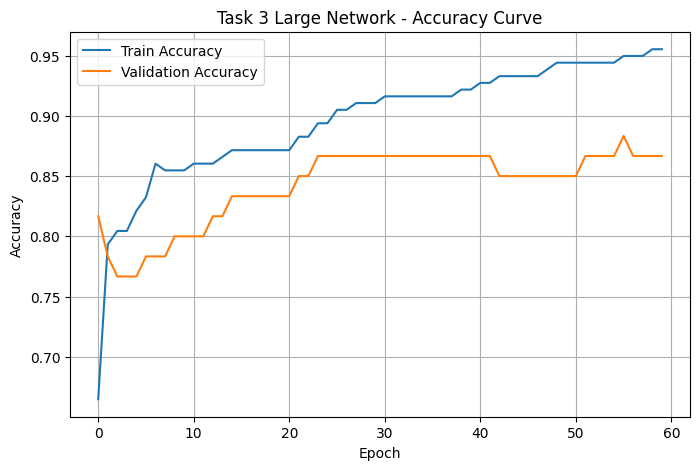

In [39]:
plot_history(history_large, title_prefix="Task 3 Large Network")

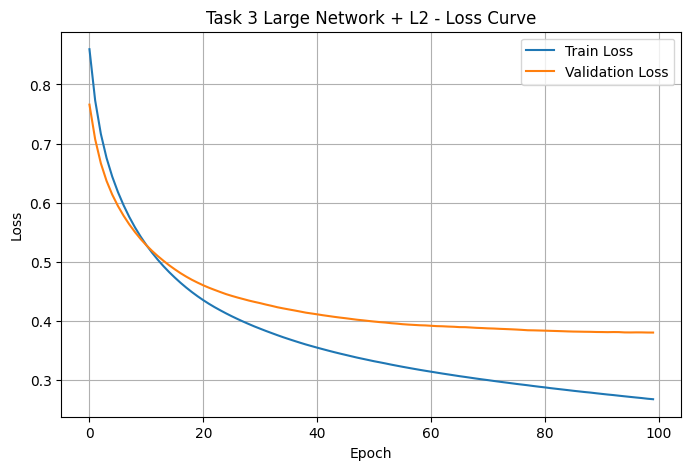

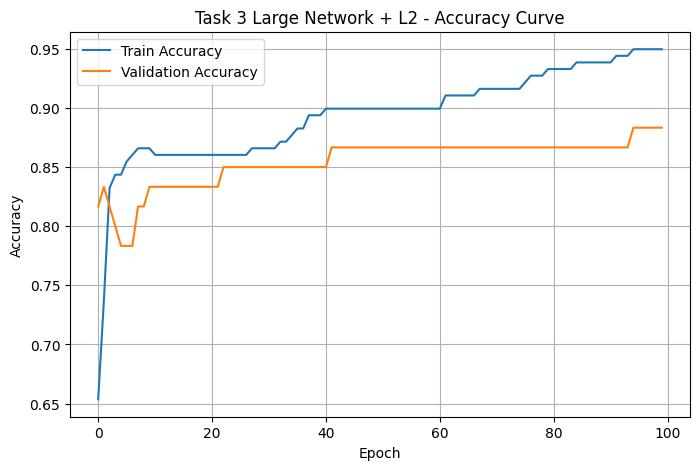

In [40]:
plot_history(history_regularised, title_prefix="Task 3 Large Network + L2")

In [41]:
task3_results = pd.DataFrame({
    "Model": ["Small Network (8)", "Large Network (128)", "Large Network + L2"],
    "Validation Accuracy": [small_val_acc, large_val_acc, reg_val_acc],
    "Validation ROC-AUC": [small_val_auc, large_val_auc, reg_val_auc],
    "Test Accuracy": [small_test_acc, large_test_acc, reg_test_acc],
    "Test ROC-AUC": [small_test_auc, large_test_auc, reg_test_auc]
})

task3_results

,Model,Validation Accuracy,Validation ROC-AUC,Test Accuracy,Test ROC-AUC
0,Small Network (8),0.800000,0.928113,0.783333,0.831836
1,Large Network (128),0.850000,0.917843,0.750000,0.799743
2,Large Network + L2,0.883333,0.925546,0.750000,0.815148


The small network has limited capacity so it may underfit the data.
The large network has more capacity and may fit the training data better but it can also overfit.

The regularised model is used to reduce overfitting. If the regularised model has better validation
performance than the large model this suggests that regularisation was helpful.

# **Task 4**

In [42]:
candidate_models = {
    "Logistic Regression": (log_reg, log_val_auc, "sklearn"),
    "MLP ReLU": (mlp_relu, mlp_val_auc, "keras"),
    "ReLU": (relu_model, relu_val_auc, "keras"),
    "tanh": (tanh_model, tanh_val_auc, "keras"),
    "Small Network": (small_model, small_val_auc, "keras"),
    "Large Network": (large_model, large_val_auc, "keras"),
    "Large Network + L2": (regularised_model, reg_val_auc, "keras")
}

best_name = None
best_model = None
best_auc = -1
best_type = None

for model_name, (model_obj, val_auc, model_type) in candidate_models.items():
    if val_auc > best_auc:
        best_auc = val_auc
        best_name = model_name
        best_model = model_obj
        best_type = model_type

print("Best model selected from validation set only:", best_name)
print("Best validation ROC-AUC:", round(best_auc, 4))

Best model selected from validation set only: Small Network
Best validation ROC-AUC: 0.9281


In [43]:

if best_type == "sklearn":
    final_test_acc, final_test_auc = evaluate_sklearn_model(
        best_model, X_test_scaled, y_test, name="Final Selected Model - Test"
    )
else:
    final_test_acc, final_test_auc = evaluate_keras_model(
        best_model, X_test_scaled, y_test, name="Final Selected Model - Test"
    )

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Final Selected Model - Test
Accuracy: 0.7833
ROC-AUC : 0.8318


In [44]:
if best_type == "keras":
    final_probs = best_model.predict(X_test_scaled).ravel()
    final_preds = (final_probs >= 0.5).astype(int)
else:
    final_probs = best_model.predict_proba(X_test_scaled)[:, 1]
    final_preds = best_model.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_preds))

print("\nClassification Report:")
print(classification_report(y_test, final_preds))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Confusion Matrix:
[[38  3]
 [10  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.93      0.85        41
           1       0.75      0.47      0.58        19

    accuracy                           0.78        60
   macro avg       0.77      0.70      0.72        60
weighted avg       0.78      0.78      0.77        60



The training set is used to fit the model.
The validation set is used to compare models and choose the best settings.
The test set is only used once at the very end for final evaluation.

This is important because using the test set during model selection would make the final result unfair.
 very small differences in scores should not be over-interpreted because they may be due to randomness.